# Percobaan 4

Percobaan ini bertujuan untuk melakukan klasifikasi citra serat kayu Nantu, Palapi, dan Uru menggunakan fitur tekstur Gray Level Co-occurrence Matrix (GLCM). Tahapan yang dilakukan meliputi pengumpulan data, augmentasi, preprocessing, ekstraksi fitur, seleksi fitur, normalisasi, pelatihan model, dan evaluasi performa klasifikasi menggunakan Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Berbeda dengan percobaan sebelumnya, pada percobaan ini dilakukan penambahan proses Mean Filter pada tahap preprocessing sebelum Median Filter dan Histogram Equalization. Kombinasi Mean Filter dan Median Filter digunakan untuk mengurangi noise sekaligus mempertahankan karakteristik tekstur citra sehingga fitur GLCM yang dihasilkan menjadi lebih representatif.

Fokus utama percobaan ini adalah menganalisis pengaruh penambahan Mean Filter terhadap kualitas citra hasil preprocessing serta performa klasifikasi dalam membedakan karakteristik tekstur serat kayu Nantu, Palapi, dan Uru.

In [2]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## Load Data

Dataset terdiri dari citra serat kayu Nantu, Palapi, dan Uru yang disimpan dalam struktur folder berdasarkan kelas. Setiap citra akan dibaca dan disimpan ke dalam array untuk diproses pada tahap berikutnya.

Kualitas data sangat mempengaruhi hasil klasifikasi. Apabila terdapat variasi pencahayaan, fokus, atau orientasi serat yang terlalu besar, maka nilai fitur tekstur yang dihasilkan dapat menjadi kurang konsisten.

In [3]:
data = []
labels = []
file_name = []
dataset_dir = "Dataset" # Gunakan nama folder dataset yang benar

if os.path.exists(dataset_dir):
    for sub_folder in os.listdir(dataset_dir):
        sub_folder_path = os.path.join(dataset_dir, sub_folder)
        if not os.path.isdir(sub_folder_path):
            continue
            
        sub_folder_files = os.listdir(sub_folder_path)
        for i, filename in enumerate(sub_folder_files):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)
            
            # Pastikan gambar berhasil dibaca (bukan file korup atau tipe file salah)
            if img is not None:
                
                img = img.astype(np.uint8)
                img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                
                data.append(img)
                labels.append(sub_folder)
                file_name.append(filename)
            else:
                print(f"Warning: Gagal membaca gambar {img_path}")

    data = np.array(data)
    labels = np.array(labels)
else:
    print(f"Direktori {dataset_dir} tidak ditemukan!")


Menampilkan 1 gambar dari setiap subfolder yang ada

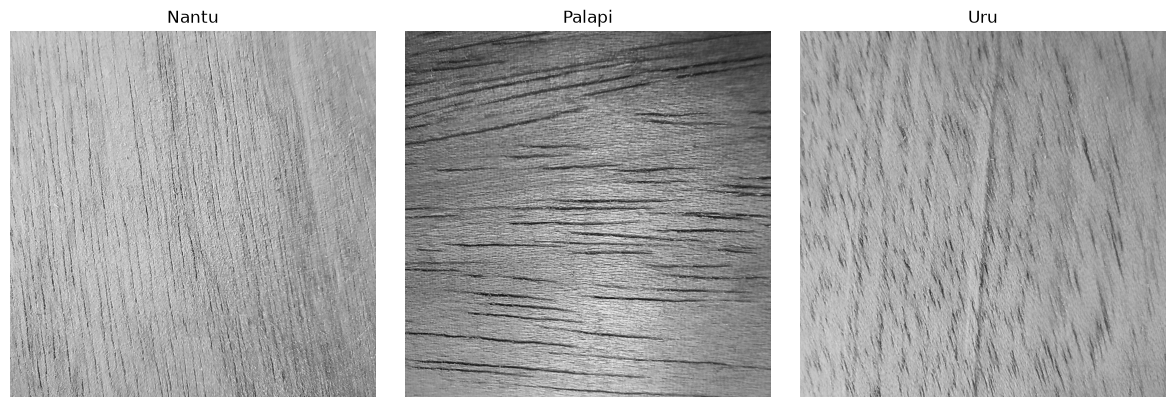

In [4]:
kelas_unik = np.unique(labels)

plt.figure(figsize=(12,4))

for i, kelas in enumerate(kelas_unik):
    
    # Cari indeks gambar pertama dari kelas tersebut
    idx = np.where(labels == kelas)[0][0]

    plt.subplot(1, len(kelas_unik), i+1)
    plt.imshow(data[idx], cmap='gray')
    plt.title(kelas)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Augmentation

Augmentasi dilakukan untuk meningkatkan jumlah data pelatihan dan memperkaya variasi pola tekstur yang dipelajari model. Teknik augmentasi dapat membantu mengurangi risiko overfitting, terutama ketika jumlah citra asli relatif terbatas.

Namun demikian, augmentasi yang berlebihan juga dapat menghasilkan sampel yang terlalu mirip dengan citra asli sehingga tidak selalu memberikan peningkatan performa yang signifikan.

In [5]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):
    img = data[i]
    label = labels[i]
    fname = file_name[i]
    
    # Citra Asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)
    
    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)
    data_augmented.append(img_flip_h)
    labels_augmented.append(label)
    file_name_augmented.append('flip_h_' + fname)
    
    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)
    data_augmented.append(img_flip_v)
    labels_augmented.append(label)
    file_name_augmented.append('flip_v_' + fname)
    
    # 3. Blur (Gaussian)
    img_blur = cv.GaussianBlur(img, (5, 5), 0)
    data_augmented.append(img_blur)
    labels_augmented.append(label)
    file_name_augmented.append('blur_' + fname)

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)
file_name_augmented = np.array(file_name_augmented)

In [6]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  315
Data setelah augmentasi:  1260


Berdasarkan hasil visualisasi, proses augmentasi berhasil menghasilkan beberapa variasi citra tanpa menghilangkan karakteristik tekstur utama dari masing-masing jenis kayu. Citra hasil *flip horizontal* dan *flip vertikal* mempertahankan pola serat kayu dengan orientasi yang berbeda, sedangkan *Gaussian blur* menghasilkan citra yang lebih halus dengan sedikit pengurangan detail tekstur. Variasi ini diharapkan dapat meningkatkan kemampuan model dalam melakukan generalisasi dan mengurangi risiko *overfitting* selama proses pelatihan.

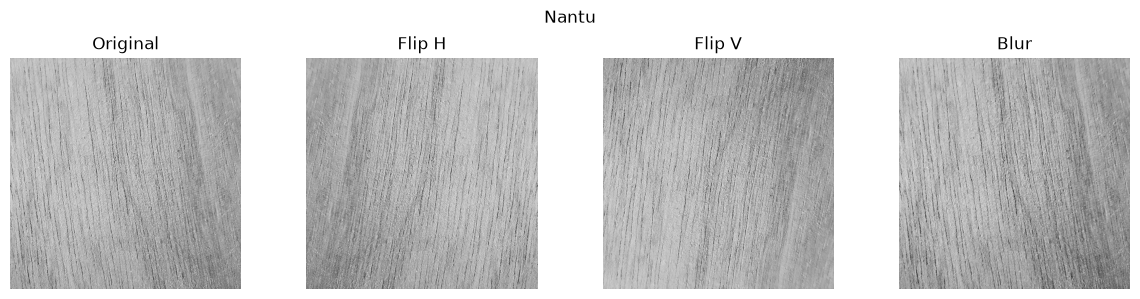

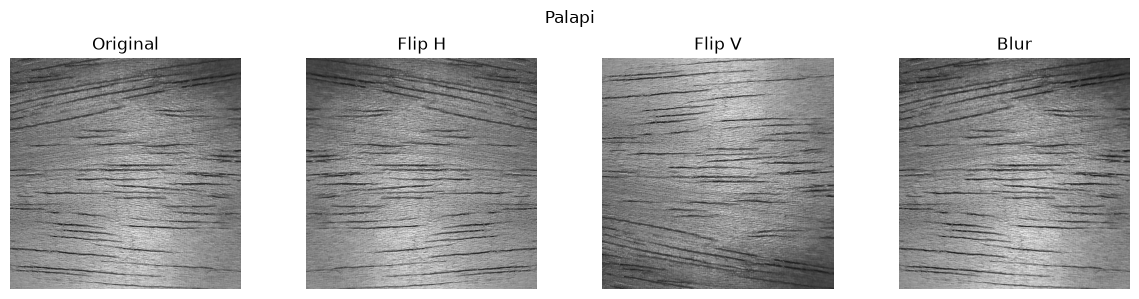

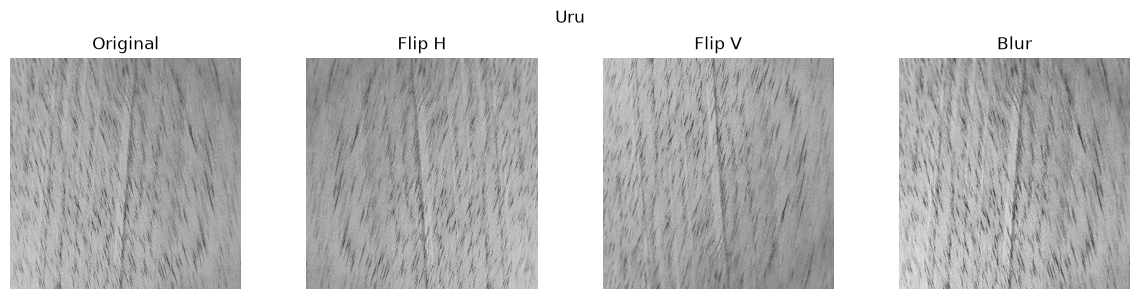

In [7]:
kelas_unik = np.unique(labels)

for kelas in kelas_unik:

    # ambil satu file asli dari kelas tersebut
    idx_asli = np.where(
        (labels_augmented == kelas) &
        (~np.char.startswith(file_name_augmented.astype(str), 'flip_h_')) &
        (~np.char.startswith(file_name_augmented.astype(str), 'flip_v_')) &
        (~np.char.startswith(file_name_augmented.astype(str), 'blur_'))
    )[0][0]

    nama_file = file_name_augmented[idx_asli]

    idx_flip_h = np.where(file_name_augmented == 'flip_h_' + nama_file)[0][0]
    idx_flip_v = np.where(file_name_augmented == 'flip_v_' + nama_file)[0][0]
    idx_blur   = np.where(file_name_augmented == 'blur_' + nama_file)[0][0]

    plt.figure(figsize=(12,3))

    plt.subplot(1,4,1)
    plt.imshow(data_augmented[idx_asli], cmap='gray')
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(data_augmented[idx_flip_h], cmap='gray')
    plt.title('Flip H')
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(data_augmented[idx_flip_v], cmap='gray')
    plt.title('Flip V')
    plt.axis('off')

    plt.subplot(1,4,4)
    plt.imshow(data_augmented[idx_blur], cmap='gray')
    plt.title('Blur')
    plt.axis('off')

    plt.suptitle(kelas)
    plt.tight_layout()
    plt.show()

## Preprocessing

Tahap preprocessing terdiri dari resize, konversi grayscale, mean filtering, median filtering, dan histogram equalization.

Tahapan ini dipilih untuk meningkatkan kualitas citra sebelum dilakukan ekstraksi fitur tekstur. Mean Filter digunakan untuk mengurangi noise dengan meratakan nilai intensitas piksel di sekitar area tertentu, sedangkan Median Filter digunakan untuk menghilangkan noise impuls tanpa menghilangkan detail tekstur secara signifikan. Setelah itu, Histogram Equalization diterapkan untuk meningkatkan kontras citra sehingga pola serat kayu menjadi lebih jelas.

Kombinasi Mean Filter dan Median Filter diharapkan mampu menghasilkan citra yang lebih bersih dan stabil untuk proses ekstraksi fitur GLCM. Dengan kualitas citra yang lebih baik, fitur tekstur yang dihasilkan dapat merepresentasikan karakteristik masing-masing jenis kayu secara lebih akurat.

Kelebihan pendekatan ini adalah mampu mengurangi noise sekaligus meningkatkan kualitas tekstur yang akan dianalisis. Namun, penggunaan beberapa tahap filtering dapat menyebabkan sebagian detail tekstur halus berkurang. Selain itu, konversi ke grayscale menghilangkan informasi warna sehingga proses klasifikasi hanya memanfaatkan karakteristik tekstur citra.

In [8]:
def resize_img(image, target_size=(128, 128)):
    return cv.resize(image, target_size)

def grayscale_filter(image):
    # Cek jika gambar sudah grayscale (hanya memiliki 2 dimensi)
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def mean_filter(image, kernel_size=3):
    return cv.blur(image, (kernel_size, kernel_size))

def median_filter(image, kernel_size=3):
    return cv.medianBlur(image, kernel_size)

def histogram_equalization(image):
    return cv.equalizeHist(image)

def preprocess_image(image):
    """
    Pipeline Preprocessing:
    1. Resize
    2. Grayscale
    3. Mean Filter
    4. Median Filter
    5. Histogram Equalization
    """
    img = resize_img(image)
    img = grayscale_filter(img)

    # Mean Filter
    img = mean_filter(img, kernel_size=3)

    # Median Filter
    img = median_filter(img, kernel_size=3)

    # Histogram Equalization
    img = histogram_equalization(img)
    
    return img

# Terapkan pipeline preprocessing ke seluruh data_augmented
# Uncomment baris di bawah ini jika ingin langsung memproses data
# preprocessed_data = np.array([preprocess_image(img) for img in data_augmented])


In [9]:
# Terapkan pipeline preprocessing ke seluruh data_augmented
print("Memulai preprocessing pada data...")
data_preprocessed = np.array([preprocess_image(img) for img in data_augmented])

print(f"Preprocessing selesai!")
print(f"Total data yang diproses: {len(data_preprocessed)}")
print(f"Bentuk data baru (shape): {data_preprocessed.shape}")


Memulai preprocessing pada data...
Preprocessing selesai!
Total data yang diproses: 1260
Bentuk data baru (shape): (1260, 128, 128)


Pada tahap ini, seluruh citra hasil augmentasi diproses menggunakan pipeline preprocessing yang telah dirancang. Tujuan preprocessing adalah meningkatkan kualitas citra sebelum dilakukan ekstraksi fitur tekstur menggunakan GLCM.

Pipeline preprocessing yang digunakan pada percobaan ini terdiri dari:

1. Resize citra menjadi ukuran 128×128 piksel.
2. Konversi citra ke grayscale.
3. Mean Filtering untuk mengurangi noise dengan metode perataan intensitas piksel.
4. Median Filtering untuk menghilangkan noise impuls dan mempertahankan tepi objek.
5. Histogram Equalization untuk meningkatkan kontras citra sehingga pola tekstur serat kayu menjadi lebih jelas.

Setelah preprocessing selesai, seluruh citra disimpan dalam variabel `data_preprocessed` dan digunakan pada tahap ekstraksi fitur berikutnya.

Visualisasi berikut menunjukkan perbandingan citra sebelum dan sesudah preprocessing untuk setiap kelas kayu, yaitu Nantu, Palapi, dan Uru.

Pada baris pertama ditampilkan citra sebelum preprocessing, sedangkan pada baris kedua ditampilkan citra setelah melalui tahapan preprocessing yang terdiri dari resize, grayscale, mean filtering, median filtering, dan histogram equalization.

Berdasarkan hasil visualisasi, proses preprocessing mampu meningkatkan kualitas citra dengan mengurangi noise serta memperjelas pola tekstur serat kayu. Penerapan Mean Filter dan Median Filter membantu menghasilkan citra yang lebih halus, sementara Histogram Equalization meningkatkan kontras sehingga detail tekstur menjadi lebih mudah diamati.

Perubahan ini diharapkan dapat membantu proses ekstraksi fitur GLCM dalam menangkap karakteristik tekstur yang lebih representatif untuk membedakan jenis kayu Nantu, Palapi, dan Uru.

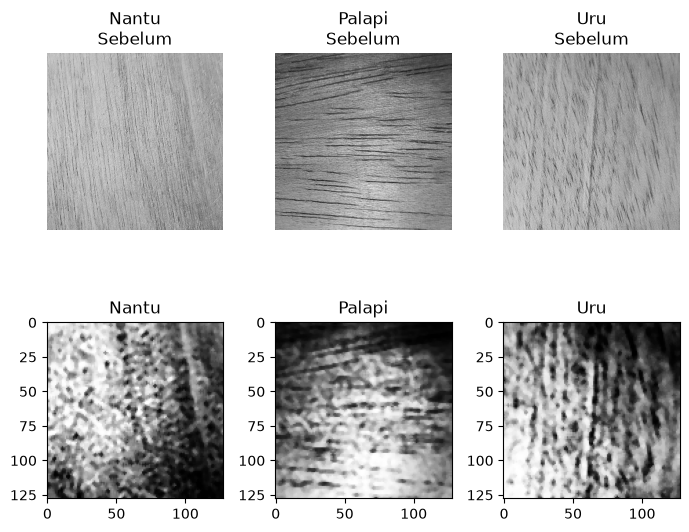

In [27]:
kelas_unik = np.unique(labels_augmented)

# Mengatur subplots: 2 baris (Sebelum di atas, Sesudah di bawah), 
# dan kolom sebanyak jumlah kelas
fig, ax = plt.subplots(2, len(kelas_unik), figsize=(7, 6))

for i, kelas in enumerate(kelas_unik):
    idx = np.where(labels_augmented == kelas)[0][0]
    
    # Baris 0 untuk Sebelum, Baris 1 untuk Sesudah
    # Kolom ditentukan oleh i (indeks kelas)
    
    # Plot Sebelum (Atas)
    ax[0, i].imshow(data_augmented[idx], cmap='gray')
    ax[0, i].set_title(f'{kelas}\nSebelum')
    ax[0, i].axis('off')
    
    # Plot Sesudah (Bawah)
    ax[1, i].imshow(data_preprocessed[idx], cmap='gray')
    ax[1, i].set_title(f'{kelas}')

plt.tight_layout()
plt.show()

## Feature Extraction

Ekstraksi fitur dilakukan menggunakan Gray Level Co-occurrence Matrix (GLCM). Metode ini dipilih karena mampu merepresentasikan karakteristik tekstur melalui hubungan spasial antar piksel.

Fitur yang digunakan meliputi Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation pada beberapa orientasi sudut.

Kelebihan GLCM adalah kemampuannya menggambarkan tekstur secara kuantitatif. Namun, performanya sangat dipengaruhi oleh parameter seperti jarak piksel (distance), sudut (angle), dan kualitas preprocessing yang digunakan.

In [11]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm_matrix = graycomatrix(
    image,
    distances=[1,2,3],
    angles=angles,
    levels=256,
    symmetric=True,
    normed=True
)

    return glcm_matrix

In [12]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Setelah matriks GLCM diperoleh, dilakukan perhitungan beberapa fitur tekstur yang digunakan sebagai representasi karakteristik citra kayu. Fitur yang diekstraksi meliputi Correlation, Dissimilarity, Homogeneity, Contrast, ASM, Energy, dan Entropy.

Fitur-fitur tersebut digunakan sebagai masukan pada tahap klasifikasi untuk membedakan tekstur serat kayu Nantu, Palapi, dan Uru.

In [13]:
for i in range(len(data_preprocessed)):
    data_preprocessed[i] = data_preprocessed[i].astype(np.uint8)

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(data_preprocessed)):
    D0 = glcm(data_preprocessed[i], 0)
    D45 = glcm(data_preprocessed[i], 45)
    D90 = glcm(data_preprocessed[i], 90)
    D135 = glcm(data_preprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks GLCM untuk setiap sudut! ---")

--- Sukses membuat matriks GLCM untuk setiap sudut! ---


Pada tahap ini, setiap citra hasil preprocessing dikonversi menjadi matriks Gray Level Co-occurrence Matrix (GLCM). Matriks GLCM dibentuk pada empat arah sudut, yaitu 0°, 45°, 90°, dan 135°.

Penggunaan beberapa sudut bertujuan untuk menangkap karakteristik tekstur dari berbagai arah sehingga informasi tekstur yang diperoleh menjadi lebih lengkap. Matriks GLCM yang dihasilkan kemudian digunakan untuk menghitung fitur-fitur tekstur pada tahap ekstraksi fitur.

In [14]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(data_preprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(data_preprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(data_preprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(data_preprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(data_preprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(data_preprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(data_preprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print("--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---")

--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---


Setelah matriks GLCM terbentuk, dilakukan ekstraksi fitur tekstur pada setiap sudut (0°, 45°, 90°, dan 135°). Fitur yang dihitung meliputi Contrast, Correlation, Dissimilarity, Homogeneity, Entropy, ASM, dan Energy.

Nilai-nilai fitur tersebut digunakan untuk merepresentasikan karakteristik tekstur citra kayu dalam bentuk numerik sehingga dapat digunakan pada proses klasifikasi.

## Penyimpanan Hasil Ekstraksi

Seluruh fitur hasil ekstraksi disimpan dalam format CSV untuk mempermudah proses analisis dan pelatihan model.

Penyimpanan fitur dalam bentuk tabel memungkinkan eksperimen dilakukan berulang kali tanpa harus menjalankan proses ekstraksi GLCM dari awal, sehingga waktu komputasi menjadi lebih efisien.

In [15]:
dataTable = {
    'Filename': file_name_augmented,
    'Label': labels_augmented,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
display(hasilEkstrak)

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,nantu_train (1).jpg,Nantu,612.251722,981.856842,559.470288,945.619629,0.241024,0.192711,0.255765,0.190909,...,0.002271,0.001633,0.046312,0.040528,0.047657,0.040416,0.943883,0.909876,0.948669,0.913189
1,flip_h_nantu_train (1).jpg,Nantu,612.251722,945.619629,559.470288,981.856842,0.241024,0.190909,0.255765,0.192711,...,0.002271,0.001643,0.046312,0.040416,0.047657,0.040528,0.943883,0.913189,0.948669,0.909876
2,flip_v_nantu_train (1).jpg,Nantu,612.251722,945.619629,559.470288,981.856842,0.241024,0.190909,0.255765,0.192711,...,0.002271,0.001643,0.046312,0.040416,0.047657,0.040528,0.943883,0.913189,0.948669,0.909876
3,blur_nantu_train (1).jpg,Nantu,454.839013,685.756836,348.242311,655.372063,0.264395,0.217275,0.294358,0.207091,...,0.003068,0.002066,0.051702,0.046080,0.055388,0.045453,0.958362,0.937142,0.968098,0.939918
4,nantu_train (10).jpg,Nantu,308.850640,724.216256,563.027990,761.391407,0.352963,0.245051,0.291646,0.242490,...,0.004264,0.003518,0.075098,0.059923,0.065303,0.059312,0.971616,0.933241,0.948185,0.929809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,blur_uru_train (98).jpg,Uru,30.576218,94.619629,74.809363,91.776986,0.393471,0.250368,0.307850,0.274038,...,0.001276,0.001107,0.042795,0.032090,0.035724,0.033272,0.997155,0.991153,0.993028,0.991417
1256,uru_train (99).jpg,Uru,94.027805,122.285139,44.714875,120.060884,0.289405,0.234027,0.365621,0.253305,...,0.001574,0.000958,0.033487,0.030013,0.039674,0.030948,0.991243,0.988575,0.995843,0.988781
1257,flip_h_uru_train (99).jpg,Uru,94.027805,120.060884,44.714875,122.285139,0.289405,0.253305,0.365621,0.234027,...,0.001574,0.000901,0.033487,0.030948,0.039674,0.030013,0.991243,0.988781,0.995843,0.988575
1258,flip_v_uru_train (99).jpg,Uru,94.027805,120.060884,44.714875,122.285139,0.289405,0.253305,0.365621,0.234027,...,0.001574,0.000901,0.033487,0.030948,0.039674,0.030013,0.991243,0.988781,0.995843,0.988575


## Feature Selection

Feature Selection dilakukan untuk mengurangi redundansi antar fitur dan menghilangkan fitur yang memiliki korelasi sangat tinggi.

Pendekatan ini bertujuan mengurangi kompleksitas model dan potensi overfitting. Namun, terdapat risiko bahwa beberapa fitur yang sebenarnya masih memiliki informasi penting ikut terhapus apabila nilai threshold korelasi ditetapkan terlalu rendah.

Hal ini dapat berdampak berbeda pada setiap algoritma. Random Forest umumnya lebih toleran terhadap fitur yang banyak, sedangkan SVM dan KNN dapat menjadi lebih sensitif terhadap proses seleksi fitur.

Jumlah fitur sebelum seleksi: 28
Jumlah fitur setelah seleksi: 12


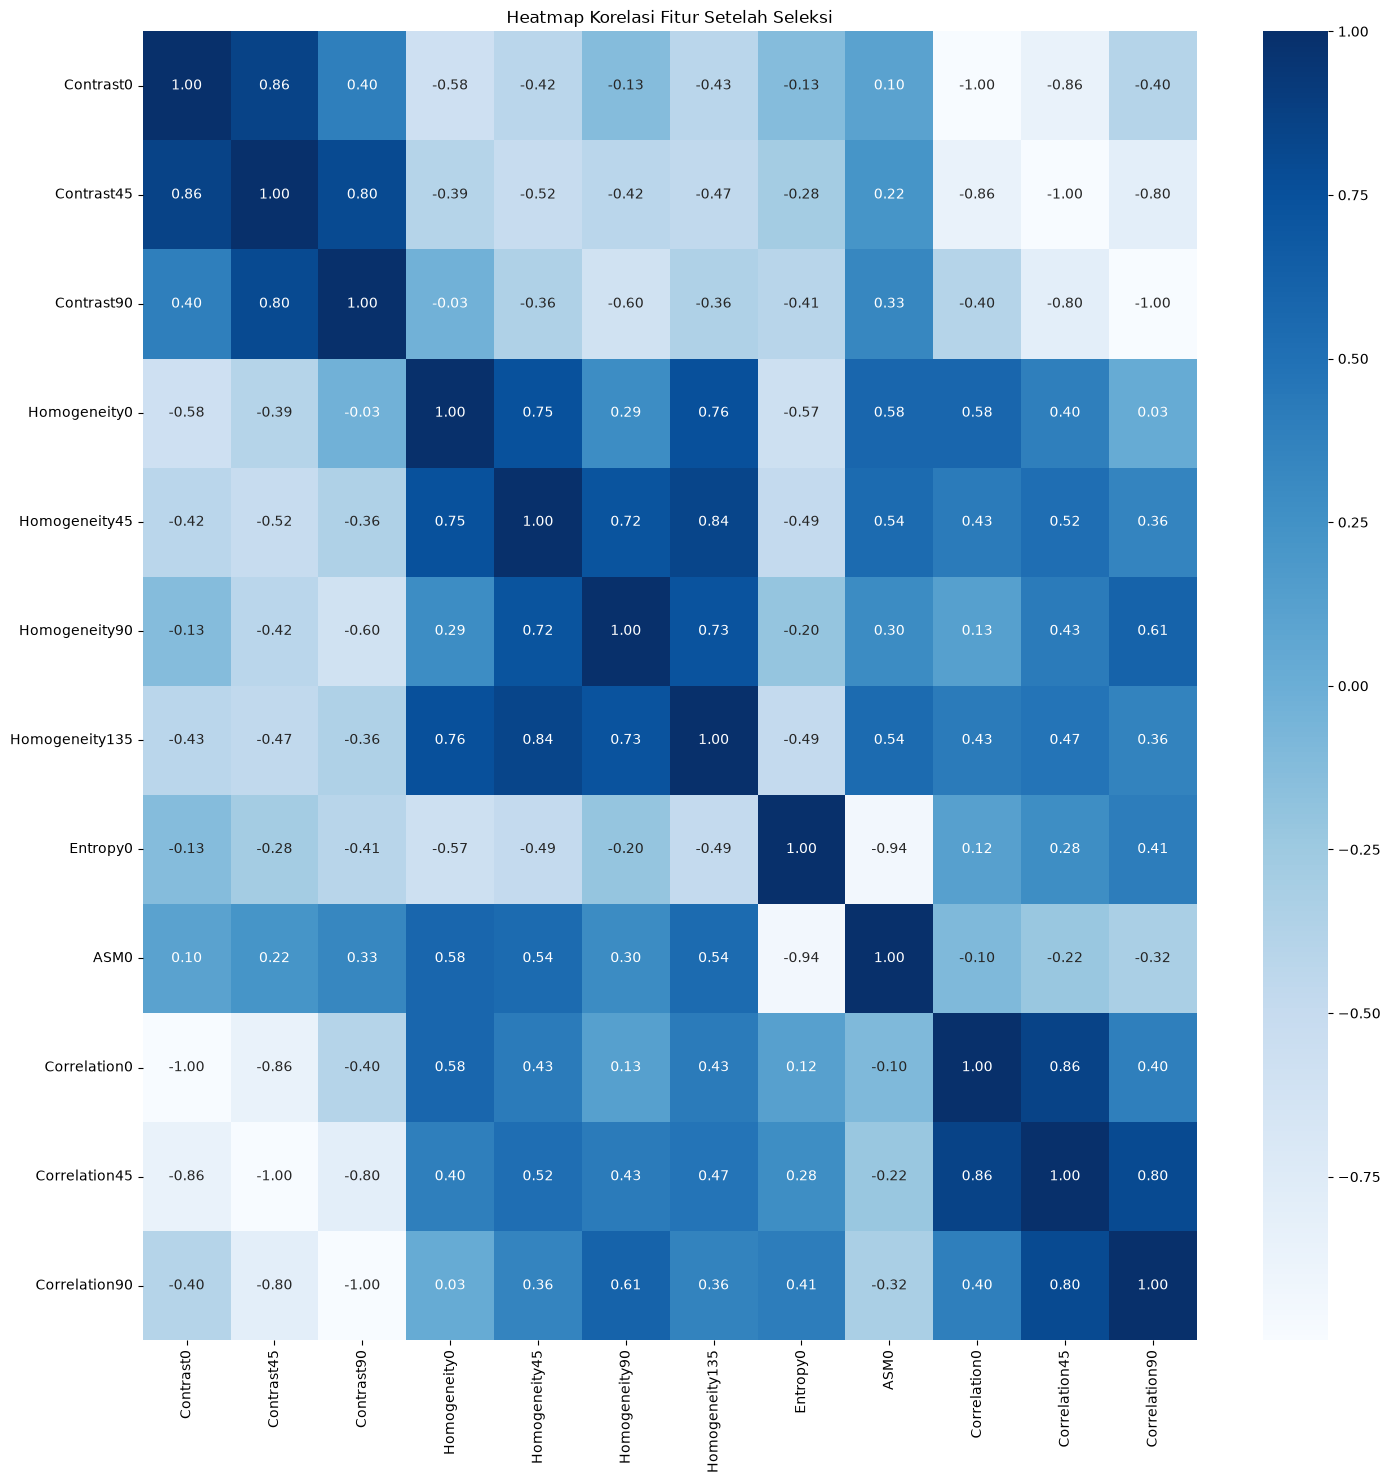

In [16]:
# Menghitung korelasi
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari threshold
threshold = 0.90
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {correlation.shape[0]}")
print(f"Jumlah fitur setelah seleksi: {x_new.shape[1]}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Setelah Seleksi')
plt.show()

## Splitting Data

Dataset dibagi menjadi data pelatihan dan data pengujian menggunakan rasio tertentu.

Pembagian ini bertujuan untuk mengevaluasi kemampuan model dalam melakukan generalisasi terhadap data yang belum pernah dilihat sebelumnya.

Salah satu keterbatasan metode hold-out adalah hasil evaluasi dapat dipengaruhi oleh pembagian data yang digunakan. Oleh karena itu, hasil akurasi sebaiknya dianalisis bersama confusion matrix dan metrik evaluasi lainnya.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1008, 12)
(252, 12)
(1008,)
(252,)


## Normalization

Normalisasi dilakukan untuk menyamakan skala antar fitur sebelum proses klasifikasi.

Langkah ini sangat penting terutama untuk algoritma berbasis jarak seperti KNN dan algoritma berbasis hyperplane seperti SVM. Tanpa normalisasi, fitur dengan rentang nilai terbesar dapat mendominasi proses pembelajaran model.

Pada penelitian ini normalisasi terbukti memberikan peningkatan performa yang signifikan terutama pada SVM dan KNN.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modeling

Tiga algoritma klasifikasi digunakan pada penelitian ini, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Random Forest dipilih karena kemampuannya menangani hubungan non-linear dan fitur dalam jumlah banyak. SVM dipilih karena dikenal memiliki performa baik pada data berdimensi tinggi. Sementara itu, KNN digunakan sebagai metode berbasis jarak yang sederhana namun efektif.

Penggunaan beberapa algoritma memungkinkan perbandingan performa sehingga dapat diketahui metode yang paling sesuai untuk karakteristik fitur tekstur yang dihasilkan.

In [19]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
svm = SVC(kernel='rbf', C=100, gamma='scale')
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

In [20]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

       Nantu       1.00      1.00      1.00       336
      Palapi       1.00      1.00      1.00       336
         Uru       1.00      1.00      1.00       336

    accuracy                           1.00      1008
   macro avg       1.00      1.00      1.00      1008
weighted avg       1.00      1.00      1.00      1008

[[336   0   0]
 [  0 336   0]
 [  0   0 336]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.96      0.96      0.96        84
      Palapi       1.00      0.98      0.99        84
         Uru       0.97      0.99      0.98        84

    accuracy                           0.98       252
   macro avg       0.98      0.98      0.98       252
weighted avg       0.98      0.98      0.98       252

[[81  0  3]
 [ 2 82  0]
 [ 1  0 83]]
Accuracy: 0.9761904761904762


In [21]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       0.96      0.97      0.96       336
      Palapi       1.00      0.96      0.98       336
         Uru       0.96      0.99      0.97       336

    accuracy                           0.97      1008
   macro avg       0.97      0.97      0.97      1008
weighted avg       0.97      0.97      0.97      1008

[[326   0  10]
 [ 11 321   4]
 [  4   0 332]]
Accuracy: 0.9712301587301587

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.95      0.89      0.92        84
      Palapi       0.99      0.96      0.98        84
         Uru       0.89      0.96      0.93        84

    accuracy                           0.94       252
   macro avg       0.94      0.94      0.94       252
weighted avg       0.94      0.94      0.94       252

[[75  1  8]
 [ 1 81  2]
 [ 3  0 81]]
Accuracy: 0.9404761904761905


In [22]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       1.00      1.00      1.00       336
      Palapi       1.00      1.00      1.00       336
         Uru       1.00      1.00      1.00       336

    accuracy                           1.00      1008
   macro avg       1.00      1.00      1.00      1008
weighted avg       1.00      1.00      1.00      1008

[[336   0   0]
 [  0 336   0]
 [  0   0 336]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.94      0.94      0.94        84
      Palapi       0.99      0.94      0.96        84
         Uru       0.95      1.00      0.98        84

    accuracy                           0.96       252
   macro avg       0.96      0.96      0.96       252
weighted avg       0.96      0.96      0.96       252

[[79  1  4]
 [ 5 79  0]
 [ 0  0 84]]
Accuracy: 0.9603174603174603


## Evaluation

Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.

Accuracy digunakan untuk mengukur tingkat prediksi yang benar secara keseluruhan. Precision dan Recall digunakan untuk melihat performa pada masing-masing kelas, sedangkan Confusion Matrix digunakan untuk mengidentifikasi pola kesalahan klasifikasi yang terjadi.

Analisis confusion matrix sangat penting karena akurasi yang tinggi belum tentu menunjukkan bahwa seluruh kelas terklasifikasi dengan baik.

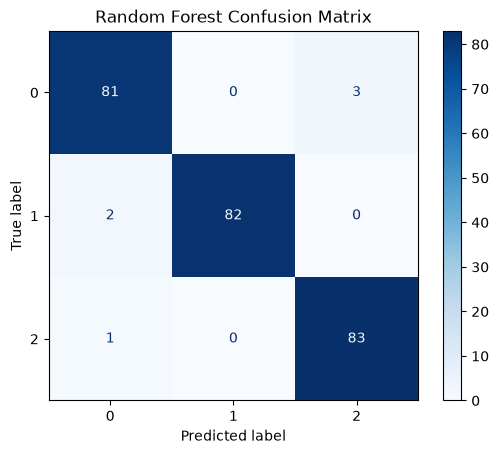

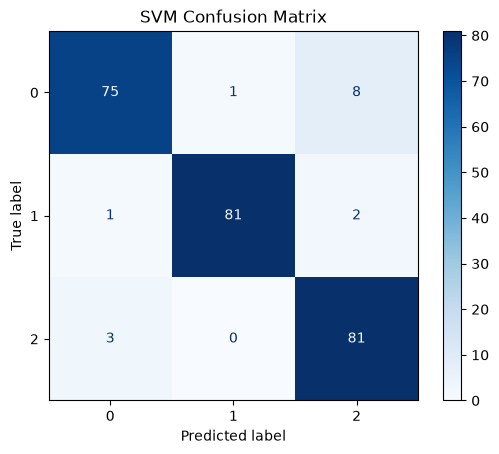

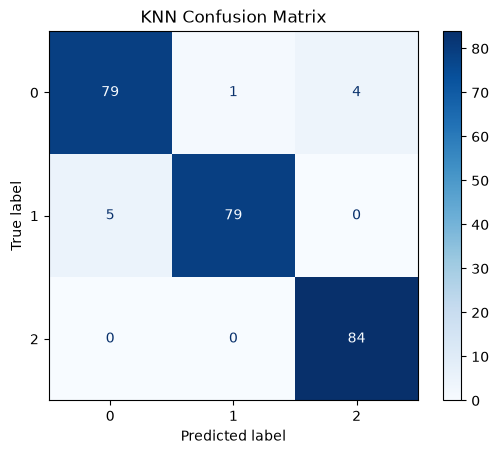

In [23]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")


## Hasil Evaluasi Model

### Tabel Perbandingan Akurasi Training dan Testing Percobaan 4

| Algoritma | Training P4 | Testing P4 |
|-----------|------------|------------|
| Random Forest | **100.00%** | **97.62%** |
| SVM | 97.12% | 94.05% |
| KNN | 100.00% | 96.03% |

### Tabel Perbandingan Metrik Evaluasi pada Data Testing Percobaan 4

| Algoritma | Precision | Recall | F1-Score | Accuracy |
|-----------|-----------|---------|----------|----------|
| Random Forest | **0.98** | **0.98** | **0.98** | **97.62%** |
| SVM | 0.94 | 0.94 | 0.94 | 94.05% |
| KNN | 0.96 | 0.96 | 0.96 | 96.03% |